# Eksperyment pierwszy
Eksperyment, w którym definiujemy dwa zbiory z różnicami w wielkości komórek. Utworzone zostaną dwa zbiory z różnicą w rozmiarze komórek w zbiorze testowym. Ma to na celu sprawdzenie czy istnieje
różnica w MSE

In [5]:
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig

conf1 = GenerationConfig()
conf1.distribution.algorithm = 'clustered'
komorka1 = ImageGenerator(conf1)

conf = GenerationConfig()
conf.axes.mean_x = 22
conf.axes.mean_y = 16
conf.axes.std_x = 6

conf.distribution.algorithm = 'clustered'

komorka2 = ImageGenerator(conf)


set1_tre = komorka1.build_batch(5000)
set1_val = komorka1.build_batch(1000)
set1_test_normal = komorka1.build_batch(2000)

set2_test_large = komorka2.build_batch(2000)

Generated 12 centers
Generated 8 centers
Generated 8 centers
Generated 10 centers
Generated 7 centers
Generated 5 centers
Generated 9 centers
Generated 4 centers
Generated 14 centers
Generated 10 centers
Generated 14 centers
Generated 12 centers
Generated 11 centers
Generated 10 centers
Generated 8 centers
Generated 4 centers
Generated 10 centers
Generated 12 centers
Generated 5 centers
Generated 12 centers
Generated 17 centers
Generated 7 centers
Generated 14 centers
Generated 13 centers
Generated 12 centers
Generated 11 centers
Generated 9 centers
Generated 12 centers
Generated 12 centers
Generated 5 centers
Generated 9 centers
Generated 9 centers
Generated 15 centers
Generated 7 centers
Generated 5 centers
Generated 7 centers
Generated 1 centers
Generated 9 centers
Generated 8 centers
Generated 11 centers
Generated 8 centers
Generated 11 centers
Generated 10 centers
Generated 7 centers
Generated 9 centers
Generated 1 centers
Generated 13 centers
Generated 11 centers
Generated 15 cen

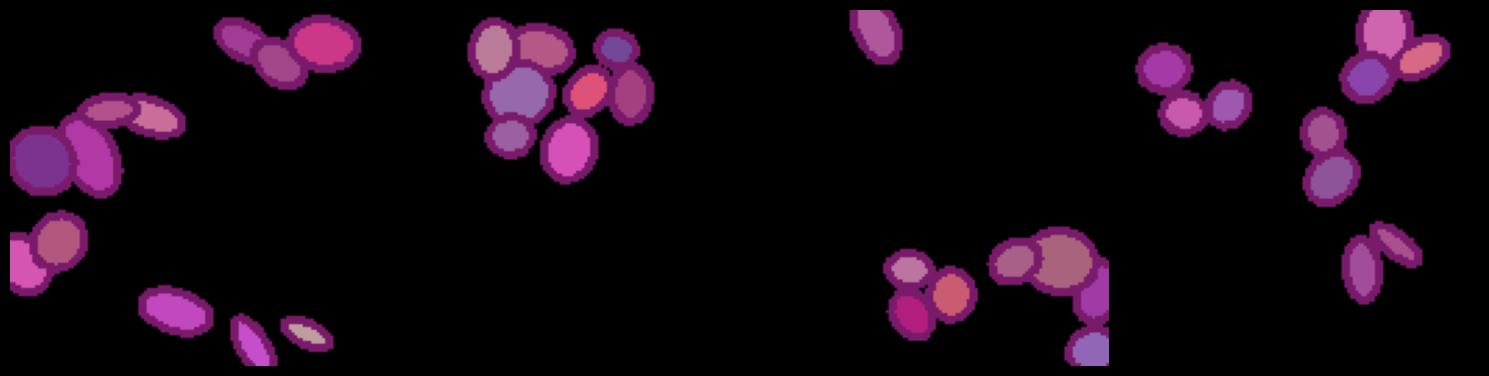

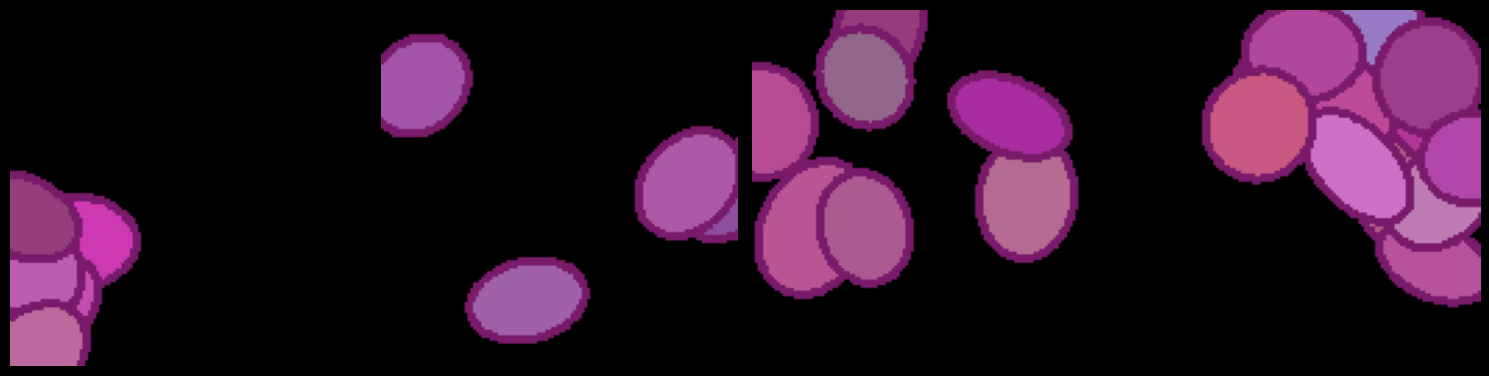

In [6]:
from src.visualization.visualize_output import show_images

show_images(set1_tre[:4])
show_images(set2_test_large[:4])

In [7]:
import numpy as np


def preprocess(data_list):
    return np.array(data_list, dtype='float32') / 255.

x_train = preprocess(set1_tre)
x_val = preprocess(set1_val)
x_test_normal = preprocess(set1_test_normal)
x_test_large = preprocess(set2_test_large)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 0.7748 - loss: 0.1288 - mse: 0.0133 - val_accuracy: 0.8240 - val_loss: 0.0919 - val_mse: 0.0023
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.2178 - loss: 0.0900 - mse: 0.0019 - val_accuracy: 0.1463 - val_loss: 0.0899 - val_mse: 0.0017
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - accuracy: 0.1363 - loss: 0.0887 - mse: 0.0016 - val_accuracy: 0.1316 - val_loss: 0.0890 - val_mse: 0.0014
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.1265 - loss: 0.0880 - mse: 0.0014 - val_accuracy: 0.1285 - val_loss: 0.0884 - val_mse: 0.0013
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.1326 - loss: 0.0877 - mse: 0.0013 - val_accuracy: 0.1242 - val_loss: 0.0880 - val_mse: 0.0012
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.4814 - loss: 0.0872 - mse: 0.0011 - val_accuracy: 0.5945 - val_loss: 0.0877 - val_mse: 0.0011
Epoch 7/50
157/157 ━━━

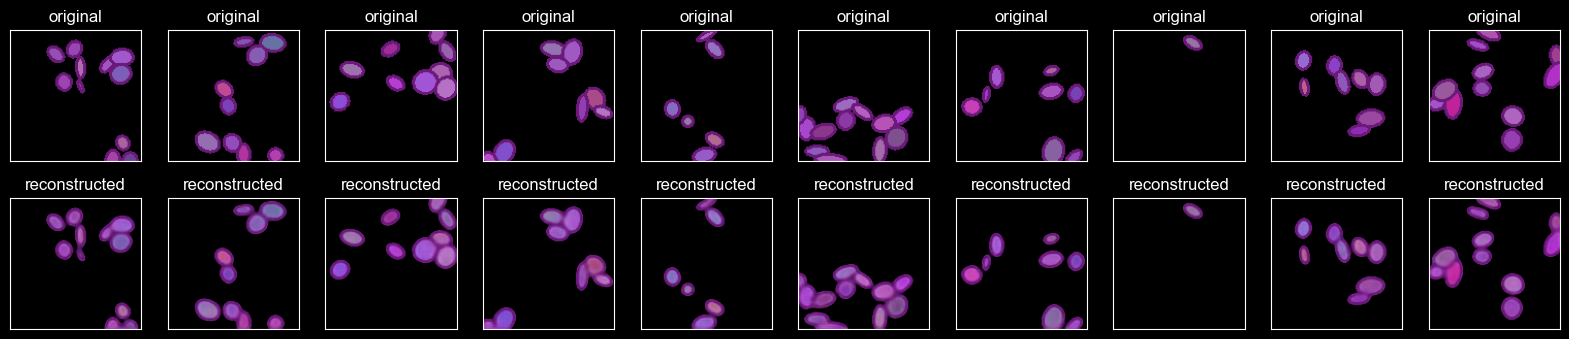

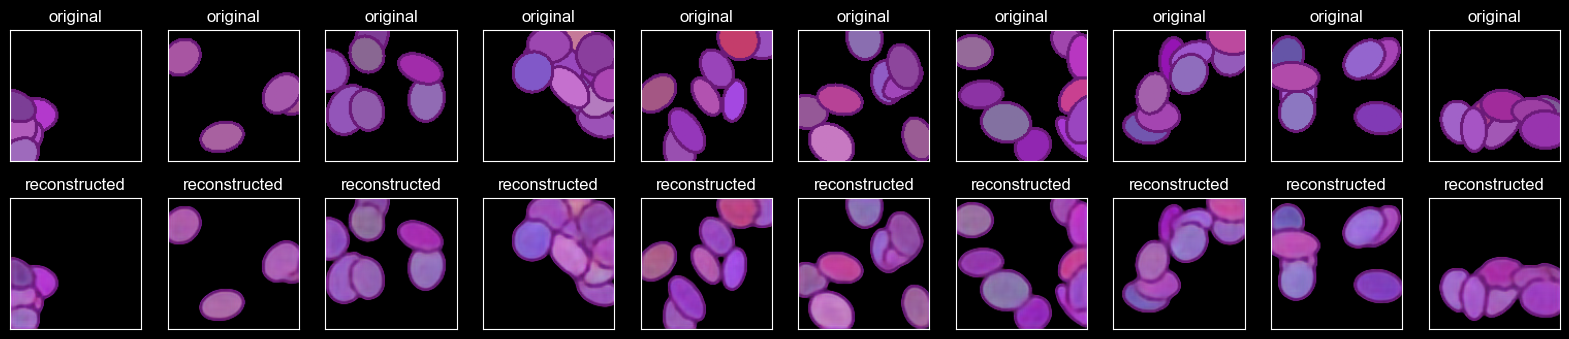

In [8]:
import keras
import numpy as np
from src.models.main import print_diag
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_train, x_train,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val, x_val),
    verbose=1
)
decoded_normal = enkoder.predict(x_test_normal)
decoded_large = enkoder.predict(x_test_large)

mse_normal = enkoder.evaluate(x_test_normal, x_test_normal, verbose=0)[0]
mse_large = enkoder.evaluate(x_test_large, x_test_large, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_normal:.6f}")
print(f"MSE Large:  {mse_large:.6f}")

visualize_output(x_test_normal, decoded_normal, 10)

visualize_output(x_test_large, decoded_large, 10)

Trening zakończony po 15 epokach. Wyniki błedu średniokwadratowego MSE przedstawiają się następująco:

Komórki normalne : 0,085
Komórki powiękosze: 0,24

Zauważono znacznie większy błąd w komórkach powiększonych. Jest to spowodowane inną strukturą wygenerowanych, co wprowadza zmiany w rozkładzie pikseli. Jednakże mimo wzrotsu błędu model nie utracił zdolności do poprawnej klasyfikacji kluczowych cech dla komórek.

Enkoder jest w stanie rozpoznawać komórki w podobnym kształcie, ale o różnych wymiarach.


In [10]:
import pandas as pd

temp = [{'Eksperymant': 'MSE Normal', 'Wynik': mse_normal},
        {'Eksperymant': 'MSE Large', 'Wynik': mse_large}
]

mse_dataset = pd.DataFrame(temp, columns=['Eksperymant', 'Wynik'])
mse_dataset


,Eksperymant,Wynik
0,MSE Normal,0.085700
1,MSE Large,0.235582


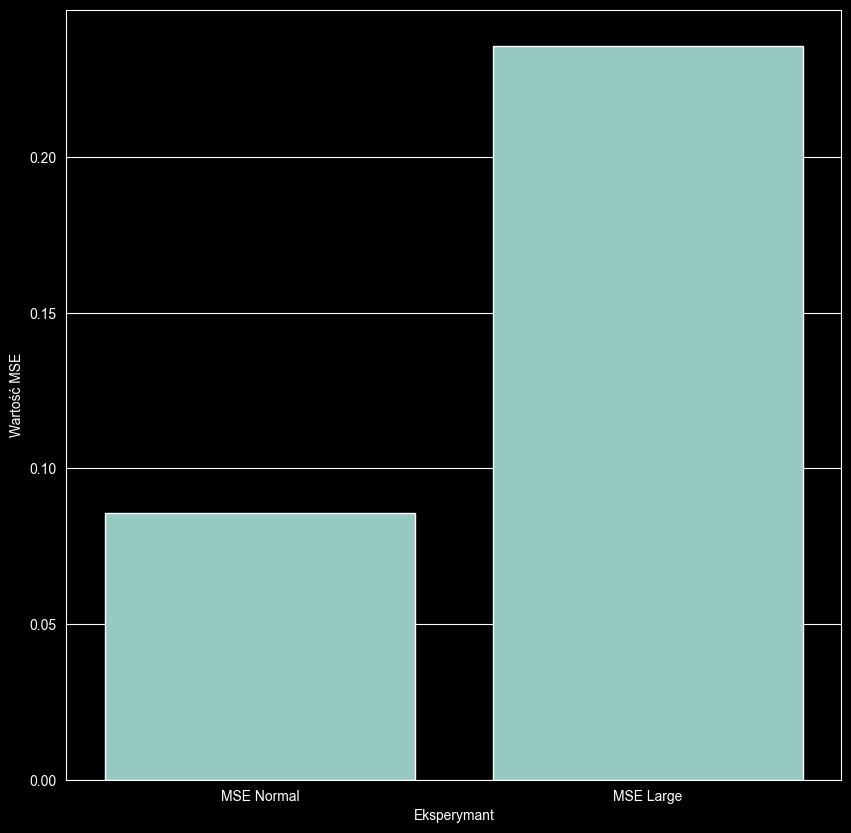

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperymant')
plt.ylabel("Wartość MSE")
plt.show()


# Eksperyment drugi
zmiana kolorów w drugim zbiorze testowym